In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = '../data/ProductsData'

In [49]:
categories = pd.read_csv('../data/ProductsData/categories.csv')
customers = pd.read_csv('../data/ProductsData/customers.csv')
employees = pd.read_csv('../data/ProductsData/employees.csv')
orders = pd.read_csv('../data/ProductsData/orders.csv')
order_details = pd.read_csv('../data/ProductsData/orderDetails.csv')
products = pd.read_csv('../data/ProductsData/products.csv')
suppliers = pd.read_csv('../data/ProductsData/suppliers.csv')
shippers = pd.read_csv('../data/ProductsData/shippers.csv')


shippers.columns

Index(['id', 'name', 'phone'], dtype='object')

In [ ]:
order_details_with_products = pd.merge(order_details, products, left_on='product_id', right_on='id', suffixes=('_order_detail', '_product'))

order_details_with_products_and_categories = pd.merge(order_details_with_products, categories, left_on='category_id', right_on='id', suffixes=('', '_category'))

orders_with_customers = pd.merge(orders, customers, left_on='customer_id', right_on='id', suffixes=('', '_customer'))

orders_with_employees = pd.merge(orders_with_customers, employees, left_on='employee_id', right_on='employee_id', suffixes=('', '_employee'))

orders_with_shippers = pd.merge(orders_with_employees, shippers, left_on='shipper_id', right_on='id', suffixes=('', '_shipper'))

combined_df = pd.merge(order_details_with_products_and_categories, orders_with_shippers, left_on='order_id', right_on='id', suffixes=('', '_order'))

combined_df = pd.merge(combined_df, suppliers, left_on='supplier_id', right_on='id', suffixes=('', '_supplier'))

columns_to_drop = ['id_product', 'id_category', 'id_customer', 'id_employee', 'id_shipper', 'id_order']
combined_df = combined_df.drop(columns=columns_to_drop, errors='ignore')

print(combined_df.head())
combined_df.to_csv('../data/ProductsData/combined_data.csv', index=False)

   id_order_detail  order_id  product_id  quantity  \
0                1     10248          11        12   
1                2     10248          42        10   
2                3     10248          72         5   
3                4     10249          14         9   
4                5     10249          51        40   

                            name  supplier_id  category_id              unit  \
0                 Queso Cabrales            5            4         1 kg pkg.   
1  Singaporean Hokkien Fried Mee           20            5   32 - 1 kg pkgs.   
2         Mozzarella di Giovanni           14            4  24 - 200 g pkgs.   
3                           Tofu            6            7  40 - 100 g pkgs.   
4          Manjimup Dried Apples           24            7  50 - 300 g pkgs.   

   price  id  ...      name_shipper           phone  id_supplier  \
0  21.00   4  ...  Federal Shipping  (503) 555-9931            5   
1  14.00   5  ...  Federal Shipping  (503) 555-9931       

In [53]:
df = pd.read_csv('../data/ProductsData/combined_data.csv')
display(df)

,id_order_detail,order_id,product_id,quantity,name,supplier_id,category_id,unit,price,id,...,name_shipper,phone,id_supplier,name_supplier,contact_supplier,address_supplier,city_supplier,postal_code_supplier,country_supplier,phone_supplier
0,1,10248,11,12,Queso Cabrales,5,4,1 kg pkg.,21.00,4,...,Federal Shipping,(503) 555-9931,5,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Calle del Rosal 4,Oviedo,33007,Spain,(98) 598 76 54
1,2,10248,42,10,Singaporean Hokkien Fried Mee,20,5,32 - 1 kg pkgs.,14.00,5,...,Federal Shipping,(503) 555-9931,20,Leka Trading,Chandra Leka,"471 Serangoon Loop, Suite #402",Singapore,0512,Singapore,555-8787
2,3,10248,72,5,Mozzarella di Giovanni,14,4,24 - 200 g pkgs.,34.80,4,...,Federal Shipping,(503) 555-9931,14,Formaggi Fortini s.r.l.,Elio Rossi,"Viale Dante, 75",Ravenna,48100,Italy,(0544) 60323
3,4,10249,14,9,Tofu,6,7,40 - 100 g pkgs.,23.25,7,...,Speedy Express,(503) 555-9831,6,Mayumi's,Mayumi Ohno,92 Setsuko Chuo-ku,Osaka,545,Japan,(06) 431-7877
4,5,10249,51,40,Manjimup Dried Apples,24,7,50 - 300 g pkgs.,53.00,7,...,Speedy Express,(503) 555-9831,24,"G'day, Mate",Wendy Mackenzie,170 Prince Edward Parade Hunter's Hill,Sydney,2042,Australia,(02) 555-5914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,514,10442,11,30,Queso Cabrales,5,4,1 kg pkg.,21.00,4,...,United Package,(503) 555-3199,5,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Calle del Rosal 4,Oviedo,33007,Spain,(98) 598 76 54
514,515,10442,54,80,Tourtière,25,6,16 pies,7.45,6,...,United Package,(503) 555-3199,25,Ma Maison,Jean-Guy Lauzon,2960 Rue St. Laurent,Montréal,H1J 1C3,Canada,(514) 555-9022
515,516,10442,66,60,Louisiana Hot Spiced Okra,2,2,24 - 8 oz jars,17.00,2,...,United Package,(503) 555-3199,2,New Orleans Cajun Delights,Shelley Burke,P.O. Box 78934,New Orleans,70117,USA,(100) 555-4822
516,517,10443,11,6,Queso Cabrales,5,4,1 kg pkg.,21.00,4,...,Speedy Express,(503) 555-9831,5,Cooperativa de Quesos 'Las Cabras',Antonio del Valle Saavedra,Calle del Rosal 4,Oviedo,33007,Spain,(98) 598 76 54


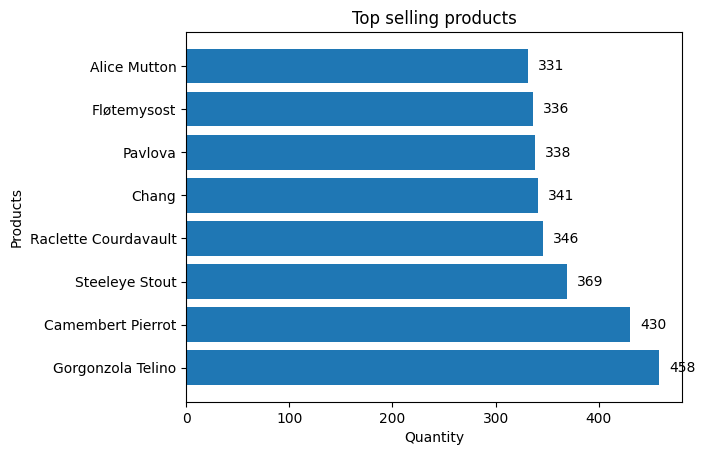

In [109]:

products_quantity = df.groupby('name')['quantity'].sum().sort_values(ascending=False)[:8]
names = np.array(products_quantity.keys())
quantities = np.array(products_quantity.values)

plt.barh(names, quantities)

for i, qty in enumerate(quantities):
    plt.text(qty + 10, i, str(qty), va='center', fontsize=10) 

plt.title("Top selling products")
plt.xlabel("Quantity")
plt.ylabel("Products")

# Show plot
plt.show()

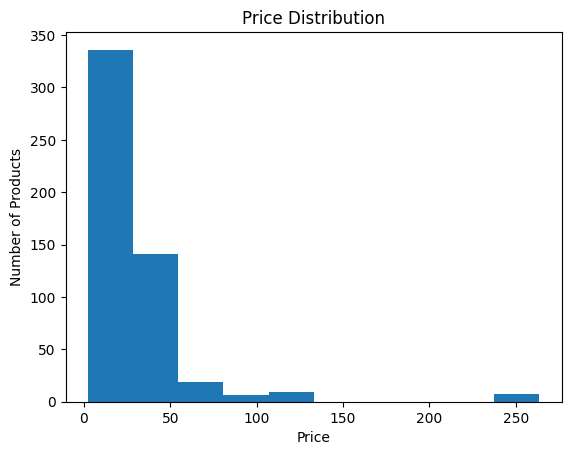

In [113]:
plt.hist(df['price'])
plt.xlabel('Price')
plt.ylabel('Number of Products')
plt.title('Price Distribution')
plt.show()